<a href="https://colab.research.google.com/github/seigdev/artificial-intelligence/blob/main/assessments/assignment_one.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install numpy==1.26.0 tensorflow==2.18.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 313.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 47.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.0 which is incompatible.


In [2]:
%pip install pandas gensim tensorflow_hub matplotlib seaborn tldextract whois rapidfuzz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.8/61.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 19.6 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1


In [1]:
import nltk
import re
import whois
import gensim
import tldextract
import seaborn as sns
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
from datetime import datetime
from functools import lru_cache
from rapidfuzz import fuzz, process
from urllib.parse import urlparse
from collections import Counter
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models

## data collection

In [2]:
# load remote dataset
try:
    datasets_raw = "https://raw.githubusercontent.com/seigdev/artificial-intelligence/refs/heads/main/crypto_url_data.json"
    datasets_df = pd.read_json(datasets_raw)
    print("✅ Data loaded successfully!")
except Exception as e:
    print(f"🚩 Error loading data: {e}")

✅ Data loaded successfully!


## EDA

In [3]:
sns.set_palette("pastel")
fontsize = 10

In [4]:
datasets_df.drop(columns=["label_no"], inplace=True)

# Map the 'label' column values: 'legit' -> 0, 'scam' -> 1
datasets_df['label'] = datasets_df['label'].map({'legit': 0, 'scam': 1})

In [5]:
datasets_df.head()

,url,label
0,https://arkham-airdrop.online,1
1,https://swiftcoinwalletparcel.pages.dev,1
2,https://traitsniper-airdrop.info,1
3,https://smardex.io,0
4,https://notcoinwallet.xyz,1


In [6]:
# Class Distribution Analysis
print("\n=== Class Distribution ===")
class_distribution = datasets_df["label"].value_counts()
print(class_distribution)


=== Class Distribution ===
label
1    50000
0    18595
Name: count, dtype: int64


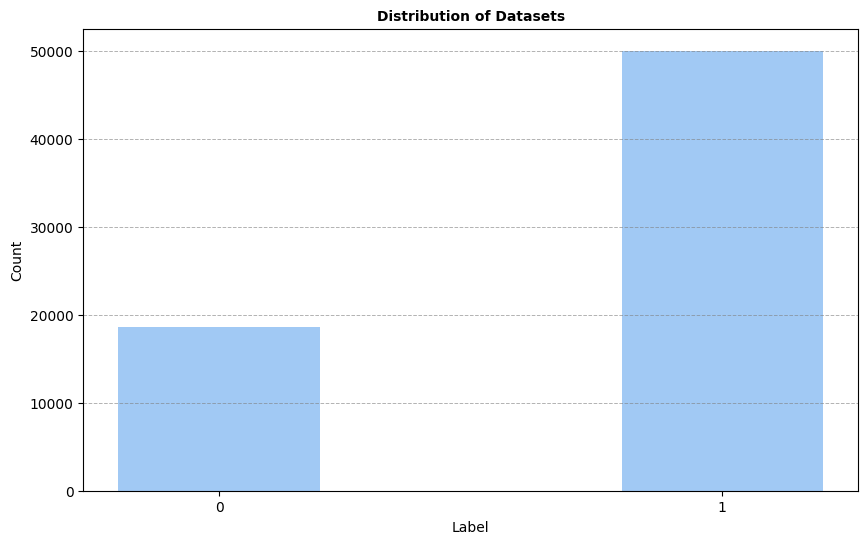

In [7]:
plt.figure(figsize=(10, 6))
bars = plt.bar(class_distribution.index, class_distribution.values, width=0.4)
plt.grid(which='major', axis='y', color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
plt.title(f"Distribution of Datasets", fontsize=fontsize, fontweight="600")
plt.xlabel("Label", fontsize=fontsize)
plt.ylabel("Count", fontsize=fontsize)
plt.xticks(class_distribution.index, fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

In [8]:
datasets_df[datasets_df["url"].isna()]

,url,label


In [9]:
print("=== URL Length Analysis ===")
datasets_df["url_length"] = datasets_df["url"].apply(len)

=== URL Length Analysis ===


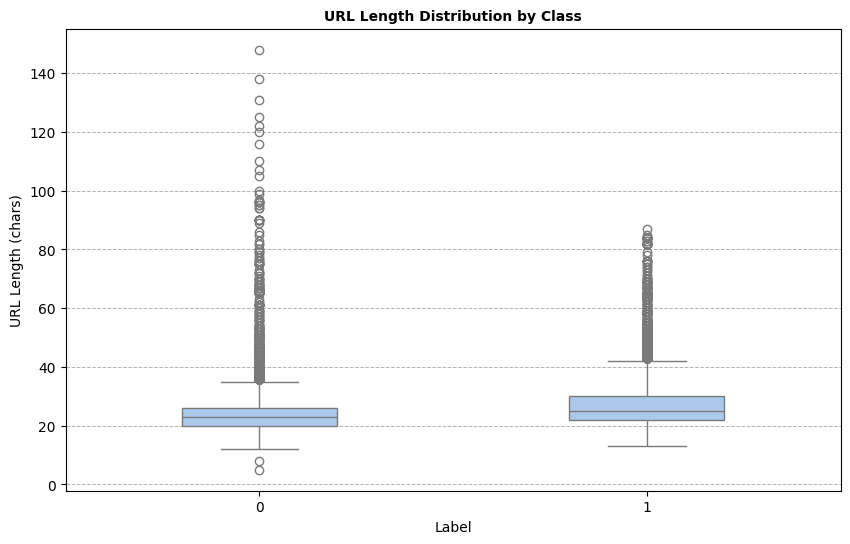

In [10]:
# Compare scam vs legit URL lengths
plt.figure(figsize=(10, 6))
sns.boxplot(x="label", y="url_length", data=datasets_df, width=0.4)
plt.grid(which='major', axis='y', color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
plt.title("URL Length Distribution by Class", fontsize=fontsize, fontweight="600")
plt.xlabel("Label", fontsize=fontsize)
plt.ylabel("URL Length (chars)", fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

In [11]:
print("=== Top 10 Scam Domain ===")
datasets_df["domain"] = datasets_df["url"].apply(lambda x: tldextract.extract(x).domain)
scam_domains = datasets_df[datasets_df["label"] == 1]["domain"].value_counts().head(10)

=== Top 10 Scam Domain ===


In [12]:
# Extract keywords from scam URLs
scam_urls = datasets_df[datasets_df["label"] == 1]["url"].tolist()
keywords = []

# List of common terms to exclude
exempted_terms = {'https', 'http', 'www', 'com', 'net', 'org', 'io', 'info'}

for url in scam_urls:
    tokens = re.split(r'[/?=&.:-]', url.lower())
    keywords.extend([t for t in tokens if len(t) > 3 and (t not in exempted_terms)])

top_keywords = Counter(keywords).most_common(10)
print("=== Top 10 Keywords in Scams ===")
print(top_keywords)

=== Top 10 Keywords in Scams ===
[('pages', 3667), ('gitbook', 2943), ('claim', 1224), ('network', 1088), ('vercel', 918), ('online', 896), ('airdrop', 841), ('site', 833), ('metamask', 756), ('help', 714)]


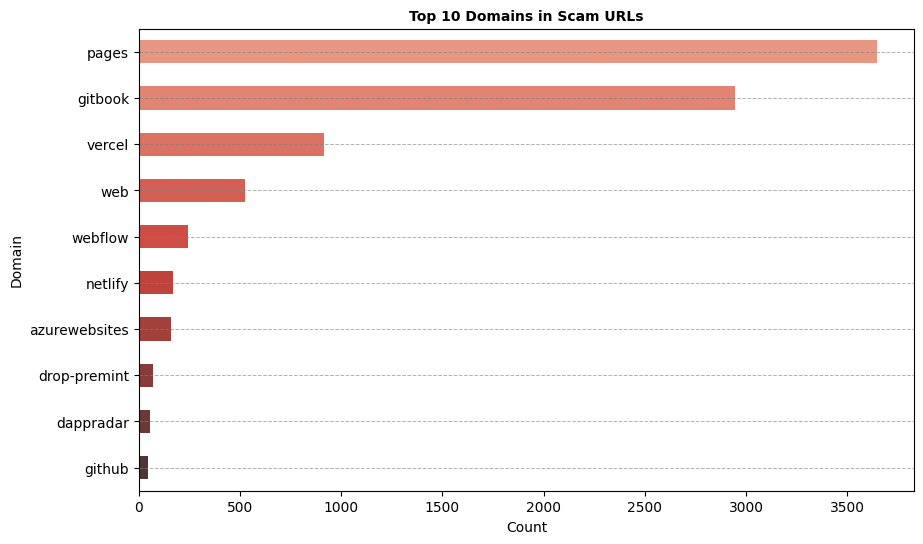

In [13]:
# Plot top scam domains
plt.figure(figsize=(10, 6))
sns.barplot(x=scam_domains.values, y=scam_domains.index, palette="Reds_d", hue=scam_domains.index, width=0.5)
plt.grid(which='major', axis='y', color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
plt.title("Top 10 Domains in Scam URLs", fontsize=fontsize,fontweight="bold")
plt.xlabel("Count", fontsize=fontsize)
plt.ylabel("Domain", fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

## preprocessing

In [14]:
def clean_url(url):

    url = url.strip().lower()

    # remove schemes
    url = re.sub(r'^https?:\/\/', '', url)

    # remove www
    url = re.sub(r'^www\.', '', url)

    # Remove TLDs (but keep the dot structure)
    url = re.sub(r'(\.[a-z]{2,3}){1,2}(?=\/|$)', '', url)

    # Tokenize by splitting on special chars
    tokens = re.split(r'[/?=&.,-]', url)
    tokens = [token for token in tokens if token and len(token) > 1]  # Drop single chars

    return " ".join(tokens)

# Apply cleaning to DataFrame
datasets_df['cleaned_url'] = datasets_df['url'].apply(clean_url)

In [15]:
datasets_df.head()

,url,label,url_length,domain,cleaned_url
0,https://arkham-airdrop.online,1,29,arkham-airdrop,arkham airdrop online
1,https://swiftcoinwalletparcel.pages.dev,1,39,pages,swiftcoinwalletparcel pages
2,https://traitsniper-airdrop.info,1,32,traitsniper-airdrop,traitsniper airdrop info
3,https://smardex.io,0,18,smardex,smardex
4,https://notcoinwallet.xyz,1,25,notcoinwallet,notcoinwallet


In [16]:
# Separate features and labels
X = datasets_df['cleaned_url']
y = datasets_df['label']

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## feature extraction

In [17]:
# define features extraction helper functions
def is_typo_squat(domain, legit_domains_set, threshold=85):
    result = process.extractOne(domain, legit_domains_set, scorer=fuzz.ratio)
    if result is None:
        return False
    match, score, _ = result
    return score >= threshold

@lru_cache(maxsize=10000)
def get_domain_age(domain):
    try:
        w = whois.whois(domain)
        creation_date = w.creation_date

        # Handle if creation_date is a list
        if isinstance(creation_date, list):
            creation_date = creation_date[0]

        if creation_date is None:
            return -1  # Unknown age

        age_days = (datetime.now() - creation_date).days
        return age_days

    except Exception as e:
        return -1  # Couldn’t determine

In [18]:
legit_domains_set = set(datasets_df[datasets_df['label'] == 0]['domain'])

In [19]:
# predefined suspicious indicators
suspicious_keywords = ["free", "bonus", "earn", "crypto", "win", "wallet",
                  "verify", "airdrop", "claim", "reward", "login"]

shortened_domains_set = {'bit.ly', 'tinyurl.com', 'goo.gl', 'ow.ly', 't.co', 'buff.ly'}

suspicious_pattern = re.compile(r"|".join(re.escape(word) for word in suspicious_keywords))
special_chars_pattern = re.compile(r"[!@#$%^&*(),?\":{}|<>]")
ip_pattern = re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b")

# feature extraction function
def extract_features(url):
    features = {}
    parsed = urlparse(url)
    ext = tldextract.extract(url)
    domain = f"{ext.domain}.{ext.suffix}"
    netloc = parsed.netloc

    features['url_length'] = len(url)
    features['has_special_chars'] = int(bool(special_chars_pattern.search(url)))
    features['has_ip_address'] = int(bool(ip_pattern.search(url)))
    features['suspicious_keywords'] = int(bool(suspicious_pattern.search(url)))
    features['is_typo_squat'] = int(is_typo_squat(ext.domain, legit_domains_set))
    features['tld'] = ext.suffix
    features['domain_age_days'] = get_domain_age(domain)
    features['is_shortened'] = int(netloc in shortened_domains_set)

    return features

# extract features for each split
train_features = pd.DataFrame([extract_features(f) for f in X_train])
test_features = pd.DataFrame([extract_features(f) for f in X_test])

# drop 'tld'
train_features.drop(columns=['tld'], inplace=True)
test_features.drop(columns=['tld'], inplace=True)

In [20]:
scaler = StandardScaler()
X_train_features_scaled = scaler.fit_transform(train_features)
X_test_features_scaled = scaler.transform(test_features)

In [21]:
map = {0: "legit", 1: "scam"}
map

{0: 'legit', 1: 'scam'}

#### Embeddings

###### word2Vec

In [22]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [23]:
# Function to convert a sentence (or URL) to a sequence of word embeddings
def sentence_to_word2vec(url, model):
    tokens = word_tokenize(url)
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(300)

In [24]:
# Train custom Word2Vec model
sentences = [word_tokenize(url) for url in datasets_df['cleaned_url'].tolist()]


# Initialize and build vocabulary in one step
word2vec_model = gensim.models.Word2Vec(
    sentences=sentences,
    vector_size=300,
    window=5,
    min_count=1,
    workers=4
)

embedding_dim = word2vec_model.vector_size

# train the word2Vec model
word2vec_model.train(
    sentences,
    total_examples=word2vec_model.corpus_count,
    epochs=10
)

def url_to_embeddings(url):
    tokens = word_tokenize(url)
    vectors = [word2vec_model.wv[token] for token in tokens if token in word2vec_model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(embedding_dim)

X_train_w2v_embed = np.array([url_to_embeddings(url) for url in X_train])
X_test_w2v_embed = np.array([url_to_embeddings(url) for url in X_test])

# print("Shape of Word2vec: Embeddings", word2vec_embeddings.shape)
print("Shape of Word2vec: X_train_w2v_embed", X_train_w2v_embed.shape)
print("Shape of Word2vec: X_test_w2v_embed", X_test_w2v_embed.shape)

Shape of Word2vec: X_train_w2v_embed (54876, 300)
Shape of Word2vec: X_test_w2v_embed (13719, 300)


###### nnlm-50

In [25]:
# load NNLM embeddings (50-dimensional)
embed_50 = hub.load("https://tfhub.dev/google/nnlm-en-dim50/2")

X_train_embed_50 = np.array([embed_50([url])[0].numpy() for url in X_train])
X_test_embed_50 = np.array([embed_50([url])[0].numpy() for url in X_test])

# print("Shape of embeddings 50: Embeddings", embeddings_50.shape)
print("X_train_embed shape:", X_train_embed_50.shape)
print("X_test_embed shape:", X_test_embed_50.shape)

X_train_embed shape: (54876, 50)
X_test_embed shape: (13719, 50)


###### nnlm-128

In [26]:
# load NNLM embeddings (128-dimensional)
embed_128 = hub.load("https://tfhub.dev/google/nnlm-en-dim128/2")

X_train_embed_128 = np.array([embed_128([url])[0].numpy() for url in X_train])
X_test_embed_128 = np.array([embed_128([url])[0].numpy() for url in X_test])

# print("Shape of embeddings_128:", embeddings_128.shape)
print("X_train_embed_128 shape:", X_train_embed_128.shape)
print("X_test_embed_128 shape:", X_test_embed_128.shape)

X_train_embed_128 shape: (54876, 128)
X_test_embed_128 shape: (13719, 128)


In [27]:
X_train_w2v_combined = np.concatenate([X_train_w2v_embed, X_train_features_scaled], axis=1)
X_test_w2v_combined = np.concatenate([X_test_w2v_embed, X_test_features_scaled], axis=1)

X_train_50_combined = np.concatenate([X_train_embed_50, X_train_features_scaled], axis=1)
X_test_50_combined = np.concatenate([X_test_embed_50, X_test_features_scaled], axis=1)

X_train_128_combined = np.concatenate([X_train_embed_128, X_train_features_scaled], axis=1)
X_test_128_combined = np.concatenate([X_test_embed_128, X_test_features_scaled], axis=1)

## Model Training & Evaluation

#### Using Multi-Layer Perceptron (Neutron) - MLP

In [28]:
def train_model(X_train, y_train, X_test, y_test, embedding_name):
    model = models.Sequential([
        layers.InputLayer(shape=(X_train.shape[1],)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Model summary
    model.summary()

    # Train the model
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

    # evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test)
    print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

    # predict on the test set
    y_pred = (model.predict(X_test) > 0.5).astype(int)

    # create confusion matrix
    confusion = confusion_matrix(y_test, y_pred)

    # print classification report
    print("\n=== Classification Report ===")
    print(classification_report(y_test, y_pred))

    # display the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=map.keys())
    disp.plot(cmap=plt.cm.Reds)
    plt.title(f"{embedding_name} Confusion Matrix")
    plt.grid(False)
    plt.show()

    return history

In [29]:
def plot_acc_history(history, title="Accuracy Over Epochs"):
    plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--')
    plt.title(title, fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)
    plt.show()

def plot_loss_history(history, title="Loss Over Epochs"):
    plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
    plt.title(title, fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)
    plt.show()

###### MLP with Word2Vec Embeddings

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        39,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,745 (186.50 KB)

 Trainable params: 47,745 (186.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8496 - loss: 0.3711 - val_accuracy: 0.8645 - val_loss: 0.3238
Epoch 2/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8658 - loss: 0.3219 - val_accuracy: 0.8678 - val_loss: 0.3147
Epoch 3/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8705 - loss: 0.3146 - val_accuracy: 0.8713 - val_loss: 0.3098
Epoch 4/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8698 - loss: 0.3158 - val_accuracy: 0.8717 - val_loss: 0.3117
Epoch 5/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8745 - loss: 0.3081 - val_accuracy: 0.8700 - val_loss: 0.3047
Epoch 6/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8724 - loss: 0.3078 - val_accuracy: 0.8772 - val_loss: 0.3000
Epoch 7/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8754 - loss: 0.3031 - val_accuracy: 0.8759 - val_loss: 0.3009
Epoch 8/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8770 - loss: 0.2984 

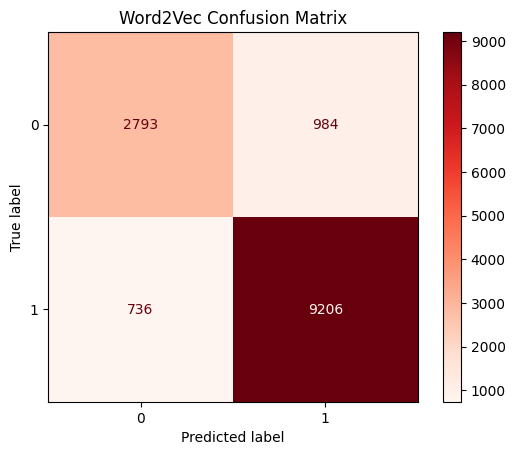

In [30]:
word2vec_hist = train_model(X_train_w2v_combined, y_train, X_test_w2v_combined, y_test, "Word2Vec")

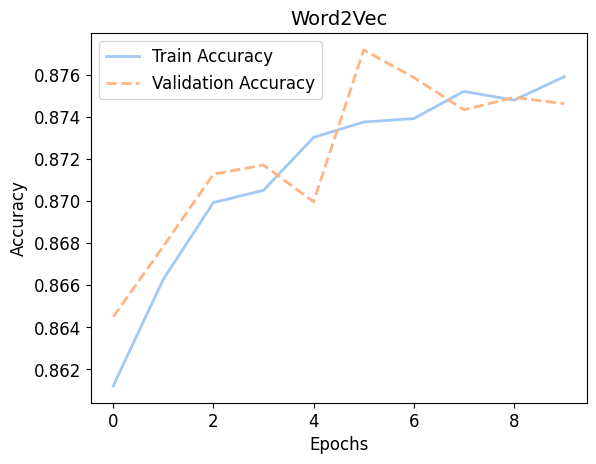

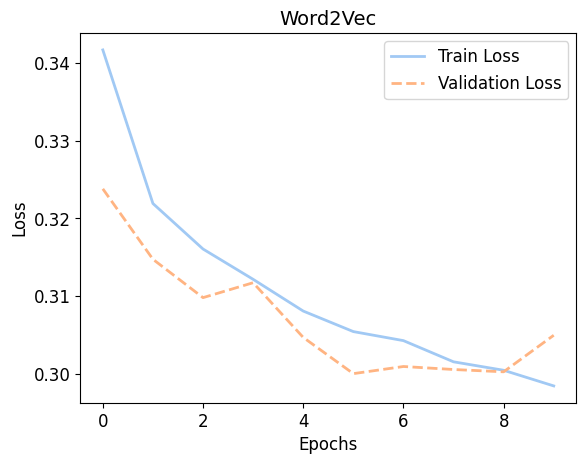

In [36]:
# validation
plot_acc_history(word2vec_hist, "Word2Vec")
print("="*40)
plot_loss_history(word2vec_hist, "Word2Vec")

###### MLP with NNLM-50 Embeddings

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,745 (61.50 KB)

 Trainable params: 15,745 (61.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8406 - loss: 0.3942 - val_accuracy: 0.8592 - val_loss: 0.3476
Epoch 2/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8658 - loss: 0.3302 - val_accuracy: 0.8649 - val_loss: 0.3304
Epoch 3/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8652 - loss: 0.3240 - val_accuracy: 0.8662 - val_loss: 0.3238
Epoch 4/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8693 - loss: 0.3142 - val_accuracy: 0.8678 - val_loss: 0.3202
Epoch 5/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8721 - loss: 0.3071 - val_accuracy: 0.8710 - val_loss: 0.3161
Epoch 6/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8711 - loss: 0.3064 - val_accuracy: 0.8704 - val_loss: 0.3146
Epoch 7/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8748 - loss: 0.2977 - val_accuracy: 0.8709 - val_loss: 0.3158
Epoch 8/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8750 - loss: 0.2963 

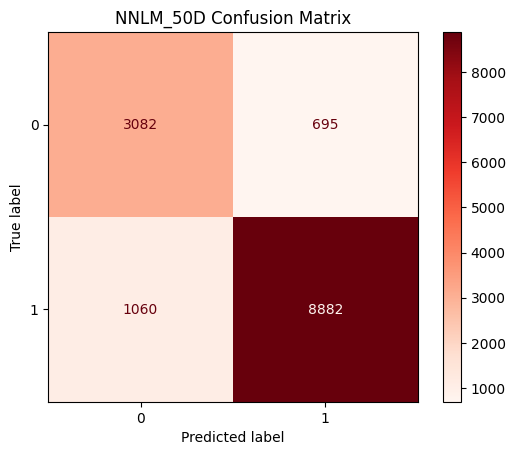

In [32]:
nnlm_50_hist = train_model(X_train_50_combined, y_train, X_test_50_combined, y_test, "NNLM_50D")

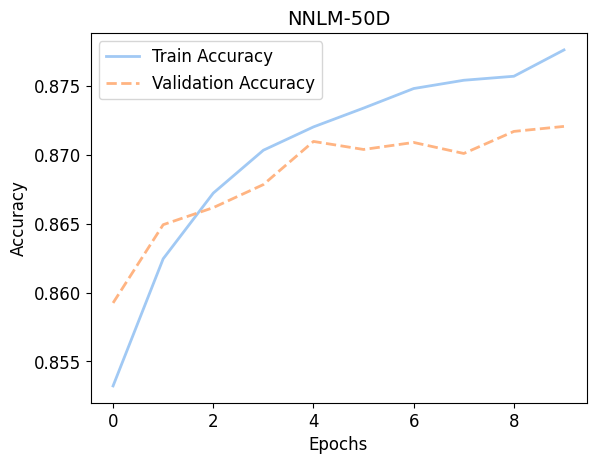

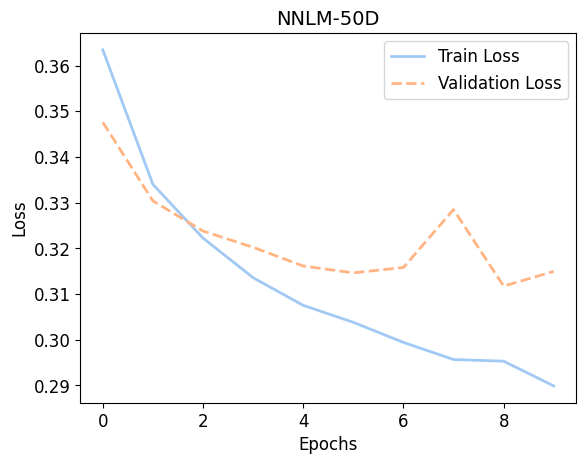

In [33]:
#
plot_acc_history(nnlm_50_hist, "NNLM-50D")
print("="*40)
plot_loss_history(nnlm_50_hist, "NNLM-50D")

###### MLP with NNLM-128 Embeddings

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,729 (100.50 KB)

 Trainable params: 25,729 (100.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8454 - loss: 0.3716 - val_accuracy: 0.8714 - val_loss: 0.3181
Epoch 2/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8744 - loss: 0.3093 - val_accuracy: 0.8721 - val_loss: 0.3092
Epoch 3/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8768 - loss: 0.2934 - val_accuracy: 0.8755 - val_loss: 0.3032
Epoch 4/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8781 - loss: 0.2879 - val_accuracy: 0.8767 - val_loss: 0.3004
Epoch 5/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8807 - loss: 0.2797 - val_accuracy: 0.8775 - val_loss: 0.2958
Epoch 6/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8851 - loss: 0.2688 - val_accuracy: 0.8771 - val_loss: 0.2982
Epoch 7/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8869 - loss: 0.2621 - val_accuracy: 0.8775 - val_loss: 0.2978
Epoch 8/10
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8862 - loss: 0.2627 -

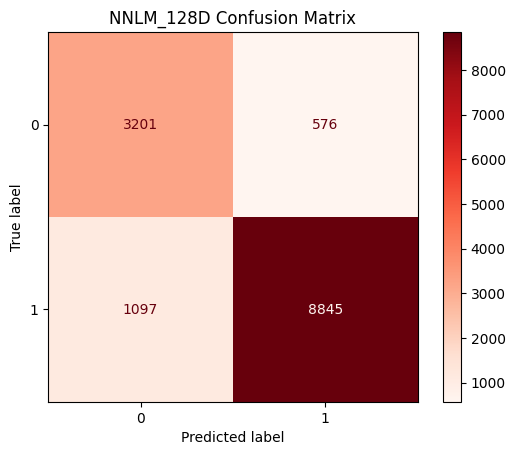

In [34]:
nnlm_128_hist = train_model(X_train_128_combined, y_train, X_test_128_combined, y_test, "NNLM_128D")

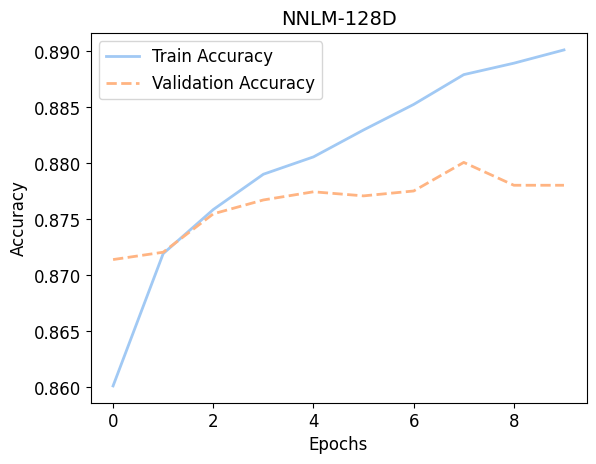

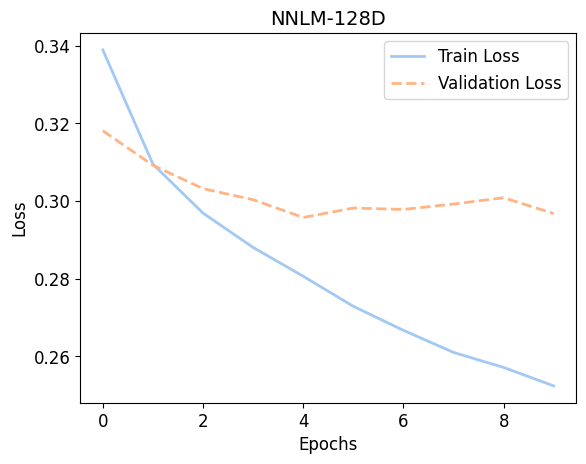

In [35]:
# plot validation
plot_acc_history(nnlm_128_hist, "NNLM-128D")
print("="*40)
plot_loss_history(nnlm_128_hist, "NNLM-128D")